In [1]:
import pyroomacoustics as pra
from scipy.io.wavfile import write

import os
import yaml
from tqdm import tqdm

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchmetrics.audio import SpeechReverberationModulationEnergyRatio, ShortTimeObjectiveIntelligibility
from torchmetrics.functional.audio import scale_invariant_signal_noise_ratio

from einops import rearrange

from src.dataset import SignalDataset, TRUNetDataset, VoiceBankDataset
from src.loss import * # loss_tot, loss_MR, loss_MR_w, phase_losses, loss_pcm, loss_ri_mag, loss_clipping_penalty, loss_compressed_MR, loss_MR_low_bins
from NISQA_s.src.core.model_torch import model_init
from NISQA_s.src.utils.process_utils import process
from torch_stoi import NegSTOILoss
from models.fspen import * # FullSubPathExtension, FullSubPathExtension_ver2, FullSubPathExtension_abs_pha, FullSubPathExtension_ver2_abs_pha, FullSubPathExtension_abs_pha_mapping, FullSubPathExtension_ver3

from src.utils import model_eval, model_eval_fspen2x_ver3, mag_phase_stft, model_eval_old, create_warmup_cosine_scheduler

import librosa
from IPython.display import Audio

import matplotlib.pyplot as plt

import warnings

In [2]:
# np.set_printoptions(precision=3)
# torch.set_printoptions(precision=3)
# TRAIN_CLEAN_DATA_DIR = "/opt/software/datasets/urgent26_track2_se_dataset/simulation_train/clean/"  # os.path.join("data", "wav48")
# TRAIN_NOISY_DATA_DIR = "/opt/software/datasets/urgent26_track2_se_dataset/simulation_train/noisy/"
DATA_DIR = os.path.join("data", "DS_10283_2791/clean_trainset_56spk_wav")
# DATA_DIR = "/opt/software/datasets/dns_challenge_v4/datasets_fullband/clean_fullband/"
# DATA_DIR = "/opt/software/datasets/urgent26_track2_se_dataset/simulation_train/clean/"
# DATA_DIR = "data/universe-validation_set-100/" # "~/opt/software/datasets/urgent26_track2_se_dataset/simulation_train/clean/"
# TEST_CLEAN_DATA_DIR = "/opt/software/datasets/urgent26_track2_se_dataset/simulation_validation/clean/"
# TEST_NOISY_DATA_DIR = "/opt/software/datasets/urgent26_track2_se_dataset/simulation_validation/noisy/"

NOISE_DIR_TRAIN = os.path.join("data", "demand_train")
# NOISE_DIR_TRAIN = os.path.join("data", "~/s3_ml_data/zdkondaurov/datasets_fullband/noise_fullband")
# NOISE_DIR_TRAIN = "/opt/software/datasets/dns_challenge_v4/datasets_fullband/noise_fullband/"
NOISE_DIR_TEST = os.path.join("data", "demand_val")

CHKP_DIR = "checkpoints"

NISQA_PATH = "NISQA_s/config/nisqa_s.yaml"
np.set_printoptions(precision=3)
torch.set_printoptions(precision=3)

In [3]:
SEED = 1984

np.random.seed(SEED)
torch.manual_seed(SEED)

gen = torch.Generator()
gen.manual_seed(SEED)

In [4]:
from torch.optim import Adam, AdamW
from src.fspen_configs import * #TrainConfig, TrainConfig_48khz, TrainConfig_48khz_RNN_Large, TrainConfig_48kHz_enc_ext, TrainConfig_48kHz_enc_ext_lay_1, TrainConfig_48kHz_enc_ext_ver2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
configs = TrainConfig_48khz()
fspen = FullSubPathExtensionTRA(configs=configs).to(DEVICE)
model_name = "TrainConfig_48khz_baseline_TRA"
# configs = TrainConfig_48khz()
# fspen = FullSubPathExtension_abs_pha(configs=configs).to(DEVICE)

optimizer = Adam(fspen.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 4, 0.98) # create_warmup_cosine_scheduler(optimizer, warmup_epochs=6, total_epochs=20, warmup_start_lr=1e-6, base_lr=1e-3, eta_min=1e-6) # torch.optim.lr_scheduler.StepLR(optimizer, 4, gamma=0.98, last_epoch=-1)

64


In [5]:
# N_FFTS = 512
# HOP_LENGTH = 256 # int(0.01625 * 16_000) # 256
N_FFTS = configs.n_fft
HOP_LENGTH = configs.hop_length
SR = configs.sample_rate
BATCH_SIZE = 2 # configs.batch_size

print(N_FFTS, HOP_LENGTH, SR)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"It's {DEVICE} time!!!")
N_DEVICES = max(torch.cuda.device_count(), 1)

1024 512 48000
It's cuda time!!!


In [6]:
with open(NISQA_PATH, 'r') as stream:
    nisqa_args = yaml.safe_load(stream)
nisqa_args["ms_n_fft"] = N_FFTS
nisqa_args["hop_length"] = HOP_LENGTH
nisqa_args["ms_win_length"] = N_FFTS
nisqa_args["ckp"] = nisqa_args["ckp"][3:]
nisqa_args["inf_device"] = DEVICE

In [7]:
nisqa, h0_nisqa, c0_nisqa = model_init(nisqa_args)

/home/zakhar/miniconda3/envs/ems_dereverb/lib/python3.10/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [8]:
from torchmetrics.audio.pesq import PerceptualEvaluationSpeechQuality
from torch_stoi import NegSTOILoss

srmr = SpeechReverberationModulationEnergyRatio(fs=16_000, norm=False)
pesq = PerceptualEvaluationSpeechQuality(fs=16_000, mode="wb").to(DEVICE)
stoi = NegSTOILoss(SR, use_vad=False, do_resample=False).to(DEVICE)

In [9]:
# rir_dict_train = {1: "~/s3_ml_data/zdkondaurov/datasets_fullband/impulse_responses"}# os.path.join("data", "rirs48_small_2_train"), 1: os.path.join("data", "rirs48_medium_2_train")}
rir_dict_train = {1: os.path.join("data", "rirs48_small_3_train"), 1: os.path.join("data", "rirs48_medium_3_train"), 1: os.path.join("data", "rirs48_large_3_train"), 1: os.path.join("data", "rirs48_super_large_3_train")}
# rir_dict_train = {1: "/opt/software/datasets/dns_challenge_v4/datasets_fullband/impulse_responses/"}
rir_dict_test = {1: os.path.join("data", "rirs48_small_3_val"), 1: os.path.join("data", "rirs48_medium_3_val"), 1: os.path.join("data", "rirs48_large_3_val"), 1: os.path.join("data", "rirs48_super_large_3_val")}
train_dataset = TRUNetDataset(DATA_DIR, sr=SR, noise_dir=NOISE_DIR_TRAIN, rir_dir=rir_dict_train, snr=[0, 5, 10, 15], rir_proba=0.85, noise_proba=0.85, rir_target=False, return_noise=False, return_rir=False, max_seq_len=SR * 4)
test_dataset = TRUNetDataset("data/DS_10283_2791/clean_trainset_28spk_wav/", sr=SR, noise_dir=NOISE_DIR_TEST, rir_dir=rir_dict_test, snr=[0, 5, 10, 15], rir_proba=1.0, noise_proba=1.0, rir_target=False, return_noise=False, return_rir=False, max_seq_len=SR * 4, partition=4_000)

train_dataset.set_epoch(1)
test_dataset.set_epoch(1)
# train_dataset = VoiceBankDataset(TRAIN_NOISY_DATA_DIR, TRAIN_CLEAN_DATA_DIR, sr=SR, max_seq_len=SR * 4)
# test_dataset = VoiceBankDataset(TEST_NOISY_DATA_DIR, TEST_CLEAN_DATA_DIR, sr=SR, max_seq_len=SR * 4)

198
56
54
12


In [10]:
print(len(train_dataset), len(test_dataset))

23075 4000


In [11]:
def vorbis_window(winlen, device="cuda"):
    sq = torch.sin(torch.pi/2*(torch.sin(torch.pi/winlen*(torch.arange(winlen)-0.5))**2)).float()
    return sq

In [12]:
def pad_sequence(batch):
    if not batch:
        return torch.zeros(0), torch.zeros(0)

    input_signal, target_signal, _, _ = zip(*batch)
        
    # max_len_s = max(s.shape[-1] for s in input_signal)
    
    # padded_input = torch.zeros(len(input_signal), max_len_s)
    # padded_target = torch.zeros(len(target_signal), max_len_s)
    
    # for i, s in enumerate(input_signal):
    #     padded_input[i, :s.shape[-1]] = s
    #     padded_target[i, :s.shape[-1]] = target_signal[i]
    # print(input_signal)
    return torch.stack(input_signal), torch.stack(target_signal)

def collate_fn(batch):
    
    padded_input, padded_target = pad_sequence(batch)

    assert torch.isnan(padded_input).any().item() is False, "waveform has NaNs"
    
    # padded_input = padded_input.unfold(-1, 16_000 * 2, 16_000)
    # padded_target = padded_target.unfold(-1, 16_000 * 2, 16_000)
    
    window = vorbis_window(N_FFTS) # torch.hann_window(N_FFTS) # vorbis_window(N_FFTS)
    
    padded_input = padded_input.reshape(-1, padded_input.shape[-1])
    input_spec = torch.stft(
            padded_input,
            n_fft=N_FFTS,
            hop_length=HOP_LENGTH,
            # onesided=True,
            win_length=N_FFTS,
            window=window,
            return_complex=True,
            normalized=True,
            center=True
            
        ) 
    # to_gt_spec = padded_target.reshape(-1, padded_target.shape[-1])
    # gt_spec = torch.stft(
    #         to_gt_spec,
    #         n_fft=N_FFTS,
    #         hop_length=HOP_LENGTH,
    #         # onesided=True,
    #         win_length=N_FFTS,
    #         window=window,
    #         return_complex=True,
    #         normalized=True,
    #         center=False
    #     ) 
    
    padded_target = padded_target.reshape(-1, padded_target.shape[-1])

    return input_spec, padded_target, padded_input


In [13]:
pin_memory = True if DEVICE == torch.device("cuda") else False
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE * N_DEVICES, shuffle=False, drop_last=False, collate_fn=collate_fn, pin_memory=pin_memory, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE * N_DEVICES, shuffle=False, drop_last=False, collate_fn=collate_fn, pin_memory=pin_memory, num_workers=4)

In [14]:
import time
def get_grad_norm(model, dict_grad):
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norm = param.grad.norm().detach().cpu().item()
            dict_grad[f"grad_norm/{name}"].append(grad_norm)
            dict_grad[f"grad_max/{name}"].append(param.grad.max().detach().cpu().item())
        else:
            dict_grad[f"grad_norm/{name}"].append(None)
            dict_grad[f"grad_max/{name}"].append(None)

    return dict_grad

def has_nan_weights(model):
    for name, param in model.named_parameters():
        if param.requires_grad:
            if torch.isnan(param).any():
                print(f"Найдены NaN в весах: {name}")
                return True
    return False

def has_nan_grads(model):
    for name, param in model.named_parameters():
        if param.grad is not None and torch.isnan(param.grad).any():
            print(f"Найдены NaN в градиентах: {name}")
            return True
    return False

def train(model, configs, train_loader, optimizer, with_noise=True, with_rir=True, device="cuda", epoch=0, accumulation_step=1, draw_every=1):
    total_train_loss = 0
    total_loss_mr = 0
    total_loss_mr_low = 0
    # total_loss_clip = 0

    total_loss_pcm = 0
    total_loss_ri_mag = 0
    total_loss_si_snr = 0
    # MOS NOI DISC COL LOUD
    total_train_nisqa = torch.zeros(5)
    total_train_srmr = []
    total_train_pesq = []
    total_train_stoi = []

    # dict_grad_norm = {}
    # for name, _ in model.named_parameters():
    #     dict_grad_norm[f"grad_norm/{name}"] = list()
    #     dict_grad_norm[f"grad_max/{name}"] = list()
    #     dict_grad_norm[f"upd_ratio/{name}"] = list()

    model.train()
    # start_step = None
    for input_spec, gt_signal, input_signal in tqdm(train_loader, desc="Train model "):
        # if start_step is not None:
        #     print("Build batch:", time.time() - start_step)
        mask = torch.isnan(input_spec).any(dim=(1, 2))
        input_spec = input_spec[~mask]
        gt_signal = gt_signal[~mask]
        input_signal = input_signal[~mask]

        input_spec = input_spec.to(device)
        gt_signal = gt_signal.to(device)
        input_signal = input_signal.to(device)
        
        # start = time.time()
        output, _ = model_eval_old(model, input_spec, configs, device, hid_size=64)
        # print("Model inference:", time.time() - start)

        window = vorbis_window(N_FFTS).to(device) # torch.hamming_window(N_FFTS).to(device) # vorbis_window(N_FFTS).to(device)

        out_wave = torch.istft(output, n_fft=N_FFTS, hop_length=HOP_LENGTH, win_length=N_FFTS,
                               window=window,
                               # onesided=True,
                               return_complex=False,
                               normalized=True,
                               center=True)#, length=gt_signal.shape[-1])
        
        min_l = min(out_wave.shape[-1], gt_signal.shape[-1])
        stoi_score = -stoi(out_wave[..., :min_l], gt_signal[..., :min_l])# .mean()# .detach().cpu()
        loss_mr = loss_MR(out_wave[..., :min_l], gt_signal[..., :min_l], nffts=[128, 256, 512, 1024], gamma=0.3)
        # loss_mr_low = loss_compressed_MR(out_wave[..., :min_l], gt_signal[..., :min_l], nffts=[128, 256, 512, 1024], gamma=0.3)
        output_real = torch.view_as_real(output[..., :min_l])
        gt_spec_real = torch.view_as_real(
            torch.stft(
                gt_signal[..., :min_l],
                n_fft=N_FFTS,
                hop_length=HOP_LENGTH,
                # onesided=True,
                win_length=N_FFTS,
                window=window,
                return_complex=True,
                normalized=True,
                center=True
            )
        )
        loss_mr_low = hybrid_loss(output_real, gt_spec_real, N_FFTS) # loss_compressed_MR(out_wave[..., :min_l], gt_signal[..., :min_l], nffts=[128, 256, 512, 1024], gamma=0.3)
        # loss_clip = loss_clipping_penalty(out_wave[..., :min_l])

        # l_pcm = loss_pcm(out_wave, gt_signal, input_signal, nffts=[128, 256, 512, 1024])
        # l_ri_mag = loss_ri_mag(out_wave, gt_signal, nffts=[128, 256, 512, 1024])
        # l_si_snr = -scale_invariant_signal_noise_ratio(out_wave - out_wave.mean(-1, keepdim=True), gt_signal - gt_signal.mean(-1, keepdim=True)).mean()
        # loss = l_pcm + l_ri_mag # + l_si_snr
        loss =  loss_mr + loss_mr_low # + loss_clip

        loss.backward()

        assert has_nan_grads(model) is False, f"Grad NaN {loss}"

        optimizer.step()
        optimizer.zero_grad()

        assert has_nan_weights(model) is False, f"NaNs in weights {loss}"

        if epoch % 5 == 0:
            srmr_score = 0 # srmr(out_wave.detach().cpu())
            # try:
            #     # start = time.time()
            #     pesq_score = pesq(out_wave[..., :min_l], gt_signal[..., :min_l])
            #     # print("PESQ:", time.time() - start)
            #     total_train_pesq.append(pesq_score.detach().cpu())
            # except Exception as e:
            #     pass
            nisqa_score, _, _ = process(out_wave.detach(), SR, nisqa, h0_nisqa, c0_nisqa, nisqa_args)
            total_train_nisqa += nisqa_score[0].detach().cpu()
            # total_train_pesq.append(pesq_score.detach().cpu())
            total_train_srmr.append(srmr_score)

        total_train_stoi.append(stoi_score.detach().cpu())
        total_train_loss += loss.detach().cpu().item()
        total_loss_mr += loss_mr.detach().cpu().item()
        total_loss_mr_low += loss_mr_low.detach().cpu().item()
        # total_loss_pcm += l_pcm.detach().cpu().item()
        # total_loss_ri_mag += l_ri_mag.detach().cpu().item()
        # total_loss_si_snr += l_si_snr.detach().cpu().item()
        # start_step = time.time()
        assert loss.detach().isnan().any().item() is False, "Train loss is NaN"
    
    if len(total_train_srmr) == 0:
        out_srmr = None
        out_pesq = None
    else:
        out_srmr = 0 # torch.hstack(total_train_srmr).mean().item()
        out_pesq = 0 # torch.hstack(total_train_pesq).mean().item()
    
    out_stoi = torch.hstack(total_train_stoi).mean().item()

    return (model, optimizer, total_train_loss / len(train_loader), total_loss_mr / len(train_dataloader),
            total_loss_mr_low / len(train_dataloader), total_loss_si_snr / len(train_dataloader),
            total_train_nisqa / len(train_loader), out_srmr, out_stoi, out_pesq)
            
def evaluate(model, configs, test_loader, with_noise=True, with_rir=True, device="cuda", epoch=0, accumulation_step=1):
    total_test_loss = 0
    total_loss_mr = 0
    total_loss_mr_low = 0
    total_loss_pcm = 0
    total_loss_ri_mag = 0
    total_loss_si_snr = 0
    total_test_nisqa = torch.zeros(5)
    total_test_srmr = []
    total_test_pesq = []
    total_test_stoi = []
    
    model.eval()

    last_out = None
    last_in = None

    with torch.no_grad():
        for input_spec, gt_signal, input_signal in tqdm(test_loader, desc="Test model "):
            mask = torch.isnan(input_spec).any(dim=(1, 2))
            input_spec = input_spec[~mask]
            gt_signal = gt_signal[~mask]
            input_signal = input_signal[~mask]

            input_spec = input_spec.to(device)
            gt_signal = gt_signal.to(device)
            input_signal = input_signal.to(device)

            output, _ = model_eval_old(model, input_spec, configs, device, hid_size=64)

            window = vorbis_window(N_FFTS).to(device) # torch.hann_window(N_FFTS).to(device) # vorbis_window(N_FFTS).to(device)
            out_wave = torch.istft(output, n_fft=N_FFTS, hop_length=HOP_LENGTH, win_length=N_FFTS,
                                   window=window,
                                   return_complex=False,
                                   normalized=True,
                                   center=True)

            min_l = min(out_wave.shape[-1], gt_signal.shape[-1])
            stoi_score = -stoi(out_wave[..., :min_l], gt_signal[..., :min_l])# .mean()# .detach().cpu()   
            loss_mr = loss_MR(out_wave[..., :min_l], gt_signal[..., :min_l], nffts=[128, 256, 512, 1024], gamma=0.3)
            # loss_mr_low = loss_compressed_MR(out_wave[..., :min_l], gt_signal[..., :min_l], nffts=[128, 256, 512, 1024], gamma=0.3)
            # loss_mr = loss_compressed_MR(out_wave[..., :min_l], gt_signal[..., :min_l], nffts=[128, 256, 512, 1024], gamma=0.3)    
            # loss_clip = loss_clipping_penalty(out_wave[..., :min_l])
            output_real = torch.view_as_real(output[..., :min_l])
            gt_spec_real = torch.view_as_real(
                torch.stft(
                    gt_signal[..., :min_l],
                    n_fft=N_FFTS,
                    hop_length=HOP_LENGTH,
                    # onesided=True,
                    win_length=N_FFTS,
                    window=window,
                    return_complex=True,
                    normalized=True,
                    center=True
                )
            )
            loss_mr_low = hybrid_loss(output_real, gt_spec_real, N_FFTS)

            # l_pcm = loss_pcm(out_wave, gt_signal, input_signal, nffts=[128, 256, 512, 1024])
            # l_ri_mag = loss_ri_mag(out_wave, gt_signal, nffts=[128, 256, 512, 1024])
            # l_si_snr = -scale_invariant_signal_noise_ratio(out_wave - out_wave.mean(-1, keepdim=True), gt_signal - gt_signal.mean(-1, keepdim=True)).mean()
            # loss = l_pcm + l_ri_mag # + l_si_snr
            loss = loss_mr + loss_mr_low # + loss_clip

            if epoch % 5 == 0:
                srmr_score = 0 #  srmr(out_wave.detach().cpu())
                total_test_pesq.append(0)
                # try:
                #     pesq_score = pesq(out_wave[..., :min_l], gt_signal[..., :min_l])
                #     total_test_pesq.append(pesq_score.detach().cpu())
                # except Exception as e:
                #     pass
                nisqa_score, _, _ = process(out_wave.detach(), SR, nisqa, h0_nisqa, c0_nisqa, nisqa_args)
                total_test_nisqa += nisqa_score[0].detach().cpu()
                # total_test_pesq.append(pesq_score.detach().cpu())
                total_test_srmr.append(srmr_score)

            total_test_stoi.append(stoi_score.detach().cpu())
            total_test_loss += loss.detach().cpu().item()
            total_loss_mr += loss_mr.detach().cpu().item()
            total_loss_mr_low += loss_mr_low.detach().cpu().item()
            # total_loss_pcm += l_pcm.detach().cpu().item()
            # total_loss_ri_mag += l_ri_mag.detach().cpu().item()
            # total_loss_si_snr += l_si_snr.detach().cpu().item()

            last_out = out_wave
            input_spec = input_spec.to(device)
            last_in = torch.istft(input_spec, n_fft=N_FFTS, hop_length=HOP_LENGTH, win_length=N_FFTS,
                                   window=window,
                                   return_complex=False,
                                   normalized=True,
                                   center=True)

            assert loss.detach().isnan().any().item() is False, "Val loss is NaN"
     
    # if epoch % 1 == 0:
    write('input_sig_part.wav', SR, last_in.cpu().detach().numpy()[0])
    write('output_part.wav', SR, last_out.cpu().detach().numpy()[0])

    if len(total_test_srmr) == 0:
        out_srmr = None
        out_pesq = None
    else:
        out_srmr = 0 # torch.hstack(total_test_srmr).mean().item()
        out_pesq = 0 # torch.hstack(total_test_pesq).mean().item()

    out_stoi = torch.hstack(total_test_stoi).mean().item()

    return (total_test_loss / len(test_loader), total_loss_mr / len(test_loader),
            total_loss_mr_low / len(test_loader), total_loss_si_snr / len(test_loader),
            total_test_nisqa / len(test_loader), out_srmr, out_stoi, out_pesq)
    

In [15]:
from IPython.display import clear_output

def get_model_name(chkp_folder, model_name=None):
    # Выбираем имя чекпоинта для сохранения
    if model_name is None:
        if os.path.exists(chkp_folder):
            num_starts = len(os.listdir(chkp_folder)) + 1
        else:
            num_starts = 1
        model_name = f'model#{num_starts}'
    else:
        if "#" not in model_name:
            model_name += "#0"
    changed = False
    while os.path.exists(os.path.join(chkp_folder, model_name + '.pt')):
        model_name, ind = model_name.split("#")
        model_name += f"#{int(ind) + 1}"
        changed=True
    if changed:
        warnings.warn(f"Selected model_name was used already! To avoid possible overwrite - model_name changed to {model_name}")
    return model_name

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def learning_loop(
    model,
    configs,
    optimizer,
    train_loader,
    val_loader,
    scheduler=None,
    min_lr=None,
    epochs=10,
    accumulation_step=1,
    val_every=1,
    draw_every=1,
    with_noise=True,
    with_rir=True,
    model_name=None,
    chkp_folder="checkpoints/fspen_chkp",
    plots=None,
    starting_epoch=0,
    device="cuda",
):
    model_name = get_model_name(chkp_folder, model_name)
    
    if plots is None:
        plots = {
            'train loss': [],
            'train loss MR': [],
            'train loss MR low': [],
            'train loss SI-SNR': [],
            'train NISQA': [],
            'train SRMR': [],
            'train STOI': [],
            'train PESQ': [],
            'val loss': [],
            'val loss MR': [],
            'val loss MR low': [],
            'val loss SI-SNR': [],
            'val NISQA': [],
            'val SRMR': [],
            'val STOI': [],
            'val PESQ': [],
            "learning rate": [],
            "weights_stat": [],
        }

    max_mos = 0

    for epoch in np.arange(1, epochs+1) + starting_epoch:
        print(f'#{epoch}/{epochs}:')
        train_dataset.set_epoch(epoch)
        # print(train_dataset.dataset.snr)
        # print(len(train_dataset.dataset.rir_files))
        test_dataset.set_epoch(epoch)
        plots['learning rate'].append(get_lr(optimizer))
        
        (model, optimizer, train_loss, train_loss_mr, train_loss_mr_low, train_loss_si_snr,
          train_nisqa, train_srmr, train_stoi, train_pesq) = train(model, configs, train_loader, optimizer, with_noise=with_noise, with_rir=with_rir, device=device, epoch=epoch - 1, accumulation_step=accumulation_step, draw_every=draw_every)
        # print(train_nisqa)
        plots['train loss'].append(train_loss)
        plots['train loss MR'].append(train_loss_mr)
        plots['train loss MR low'].append(train_loss_mr_low)
        plots['train loss SI-SNR'].append(train_loss_si_snr)
        if (epoch - 1) % 5 == 0:
            plots['train NISQA'].append(train_nisqa[None, :].cpu())
            plots['train SRMR'].append(train_srmr)
            plots['train PESQ'].append(train_pesq)
        else:
            plots['train NISQA'].append(plots['train NISQA'][-1])
            plots['train SRMR'].append(plots['train SRMR'][-1])
            plots['train PESQ'].append(plots['train PESQ'][-1])

        plots['train STOI'].append(train_stoi)
        # plots["weights_stat"].append(weights_stat)

        # print(weights_stat)
        # for name, value in weights_stat.items():
        #     writer.add_scalar(name, sum(value) / len(value), epoch)

        if not (epoch % val_every):
            # print("validate")
            (val_loss, val_loss_mr, val_loss_mr_low, val_loss_si_snr, val_nisqa, val_srmr, val_stoi, val_pesq) = evaluate(model, configs, val_loader, with_noise=with_noise, with_rir=with_rir, epoch=epoch-1, accumulation_step=accumulation_step, device=device)
            plots['val loss'].append(val_loss)
            plots['val loss MR'].append(val_loss_mr)
            plots['val loss MR low'].append(val_loss_mr_low)
            plots['val loss SI-SNR'].append(val_loss_si_snr)
            if (epoch - 1) % 5 == 0:
                plots['val NISQA'].append(val_nisqa[None, :].cpu())
                plots['val SRMR'].append(val_srmr)
                plots['val PESQ'].append(val_pesq)
            else:
                plots['val NISQA'].append(plots['val NISQA'][-1])
                plots['val SRMR'].append(plots['val SRMR'][-1])
                plots['val PESQ'].append(plots['val PESQ'][-1])

            plots['val STOI'].append(val_stoi)
            
        # Сохраняем модель
        if not os.path.exists(chkp_folder):
            os.makedirs(chkp_folder)
        
        # if max_mos <= val_nisqa[0]:
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'plots': plots,
            },
            os.path.join(chkp_folder, model_name + '.pt'),
        )

        if plots['val NISQA'][-1][0][0] > max_mos:
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'plots': plots,
                },
                os.path.join(chkp_folder, model_name + "_best_mos" + '.pt'),
            )
            
            max_mos = plots['val NISQA'][-1][0][0]
        
        # Шедулинг
        if scheduler:
            try:
                scheduler.step()
            except:
                scheduler.step(metrics=val_loss)

        if not (epoch % draw_every):
            clear_output(True)

            hh = 4
            ww = 2
            plt_ind = 1
            fig, ax = plt.subplots(hh, ww, figsize=(25, 12))
            fig.suptitle(f'#{epoch}/{epochs}:')


            plt.subplot(hh, ww, plt_ind)
            plt.title('Learning rate')
            plt.plot(plots["learning rate"], 'b.-', label='lr', alpha=0.7)
            plt.legend()
            plt_ind += 1

            plt.subplot(hh, ww, plt_ind)
            plt.title('Loss')
            plt.plot(np.arange(1, epoch + 1), plots['train loss'], 'r.-', label='train', alpha=0.7)
            plt.plot(np.arange(1, epoch + 1), plots['val loss'], 'g.-', label='val', alpha=0.7)
            plt.grid()
            plt.legend()
            plt_ind += 1
            
            plt.subplot(hh, ww, plt_ind)
            plt.title('Loss MR')
            plt.plot(np.arange(1, epoch + 1), plots['train loss MR'], 'r.-', label='train', alpha=0.7)
            plt.plot(np.arange(1, epoch + 1), plots['val loss MR'], 'g.-', label='val', alpha=0.7)
            plt.grid()
            plt.legend()
            plt_ind += 1
            
            plt.subplot(hh, ww, plt_ind)
            plt.title('STOI')
            plt.plot(np.arange(1, epoch + 1), plots['train STOI'], 'r.-', label='train', alpha=0.7)
            plt.plot(np.arange(1, epoch + 1), plots['val STOI'], 'g.-', label='val', alpha=0.7)
            plt.grid()
            plt.legend()
            plt_ind += 1

            plt.subplot(hh, ww, plt_ind)
            plt.title('Loss MR low')
            plt.plot(np.arange(1, epoch + 1), plots['train loss MR low'], 'r.-', label='train', alpha=0.7)
            plt.plot(np.arange(1, epoch + 1), plots['val loss MR low'], 'g.-', label='val', alpha=0.7)
            plt.grid()
            plt.legend()
            plt_ind += 1

            plt.subplot(hh, ww, plt_ind)
            plt.title('Loss')
            plt.plot(np.arange(1, epoch + 1), plots['train loss SI-SNR'], 'r.-', label='train', alpha=0.7)
            plt.plot(np.arange(1, epoch + 1), plots['val loss SI-SNR'], 'g.-', label='val', alpha=0.7)
            plt.grid()
            plt.legend()
            plt_ind += 1

            nisqa_plot = torch.cat(plots['train NISQA'])
            # if len(nisqa_plot.shape) == 1:
            #     nisqa_plot = nisqa_plot[None, :]
            # print(nisqa_plot.shape)
            plt.subplot(hh, ww, plt_ind)
            plt.title('Train NISQA')
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 0], '.-', label='MOS', alpha=0.7, markersize=20, color="blue")
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 1], '.-', label='NOI', alpha=0.7, markersize=20, color="red")
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 2], '.-', label='DISC', alpha=0.7, markersize=20, color="green")
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 3], '.-', label='COL', alpha=0.7, markersize=20, color="yellow")
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 4], '.-', label='LOUD', alpha=0.7, markersize=20, color="pink")
            plt.grid()
            plt.legend()
            plt_ind += 1

            nisqa_plot = torch.cat(plots['val NISQA'], dim=0)
            # if len(nisqa_plot.shape) == 1:
            #     nisqa_plot = nisqa_plot[None, :]
            plt.subplot(hh, ww, plt_ind)
            plt.title('Val NISQA')
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 0], '.-', label='MOS', alpha=0.7, markersize=20, color="blue")
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 1], '.-', label='NOI', alpha=0.7, markersize=20, color="red")
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 2], '.-', label='DISC', alpha=0.7, markersize=20, color="green")
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 3], '.-', label='COL', alpha=0.7, markersize=20, color="yellow")
            plt.plot(np.arange(1, epoch + 1), nisqa_plot[:, 4], '.-', label='LOUD', alpha=0.7, markersize=20, color="pink")
            plt.grid()
            plt.legend()
            plt_ind += 1

            plt.show()
            # display(fig)
                        
        # if min_lr and get_lr(optimizer) <= min_lr:
        #     print(f'Learning process ended with early stop after epoch {epoch}')
        #     break

    return model, optimizer, plots

In [16]:
from src.utils import model_num_params

_, _ = model_num_params(fspen)

full_band_encoder.full_band_encoder.0.conv.weight ~  48        params ~ grad: True
full_band_encoder.full_band_encoder.0.conv.bias ~  4         params ~ grad: True
full_band_encoder.full_band_encoder.0.norm.weight ~  4         params ~ grad: True
full_band_encoder.full_band_encoder.0.norm.bias ~  4         params ~ grad: True
full_band_encoder.full_band_encoder.1.conv.weight ~  512       params ~ grad: True
full_band_encoder.full_band_encoder.1.conv.bias ~  16        params ~ grad: True
full_band_encoder.full_band_encoder.1.norm.weight ~  16        params ~ grad: True
full_band_encoder.full_band_encoder.1.norm.bias ~  16        params ~ grad: True
full_band_encoder.full_band_encoder.2.conv.weight ~  3.072     params ~ grad: True
full_band_encoder.full_band_encoder.2.conv.bias ~  32        params ~ grad: True
full_band_encoder.full_band_encoder.2.norm.weight ~  32        params ~ grad: True
full_band_encoder.full_band_encoder.2.norm.bias ~  32        params ~ grad: True
full_band_encode

In [17]:
print(fspen)

FullSubPathExtensionTRA(
  (full_band_encoder): TRAFullBandEncoder(
    (full_band_encoder): ModuleList(
      (0): FullBandEncoderBlock(
        (conv): Conv1d(2, 4, kernel_size=(6,), stride=(2,), padding=(2,))
        (norm): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activate): ELU(alpha=1.0)
      )
      (1): FullBandEncoderBlock(
        (conv): Conv1d(4, 16, kernel_size=(8,), stride=(2,), padding=(3,))
        (norm): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activate): ELU(alpha=1.0)
      )
      (2): FullBandEncoderBlock(
        (conv): Conv1d(16, 32, kernel_size=(6,), stride=(2,), padding=(2,))
        (norm): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activate): ELU(alpha=1.0)
      )
    )
    (global_features): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
    (tra_conv1): TRAEncoderBlock(
      (conv1): Conv1d(16, 48, kernel_size=(3,)

In [18]:
# configs.end_bands, configs.widths

([8, 8, 16, 32, 64, 128], [16, 16, 32, 64, 128, 257])

0 16 torch.Size([1504, 1, 16]) torch.Size([1504, 32, 8])
16 32 torch.Size([1504, 1, 16]) torch.Size([1504, 32, 8])
32 64 torch.Size([1504, 1, 32]) torch.Size([1504, 32, 16])
64 128 torch.Size([1504, 1, 64]) torch.Size([1504, 32, 32])
128 256 torch.Size([1504, 1, 128]) torch.Size([1504, 32, 64])
256 513 torch.Size([1504, 1, 257]) torch.Size([1504, 32, 128])

torch.Size([752, 32, 64])
torch.Size([752, 512])

In [19]:
fspen, optimizer, plots = learning_loop(fspen, configs, optimizer, train_dataloader, test_dataloader, scheduler, draw_every=1, epochs=75, accumulation_step=1, min_lr=1e-8, with_noise=False, with_rir=False, model_name=model_name)

/tmp/ipykernel_1073204/4278129380.py:20: UserWarning: Selected model_name was used already! To avoid possible overwrite - model_name changed to TrainConfig_48khz_baseline_TRA#1
  warnings.warn(f"Selected model_name was used already! To avoid possible overwrite - model_name changed to {model_name}")


#1/75:


Train model :   0%|          | 0/11538 [00:00<?, ?it/s]

Train model :   0%|          | 30/11538 [00:05<32:43,  5.86it/s] 


KeyboardInterrupt: 

In [ ]:
# state_d = torch.load(os.path.join(CHKP_DIR, "fspen_chkp", "TrainConfig48kHzEnc_abs_pha_charisma#0.pt"), weights_only=False)

# fspen.load_state_dict(state_d["model_state_dict"])
# optimizer.load_state_dict(state_d["optimizer_state_dict"])
# scheduler.load_state_dict(state_d["scheduler_state_dict"])
# plots = state_d["plots"]

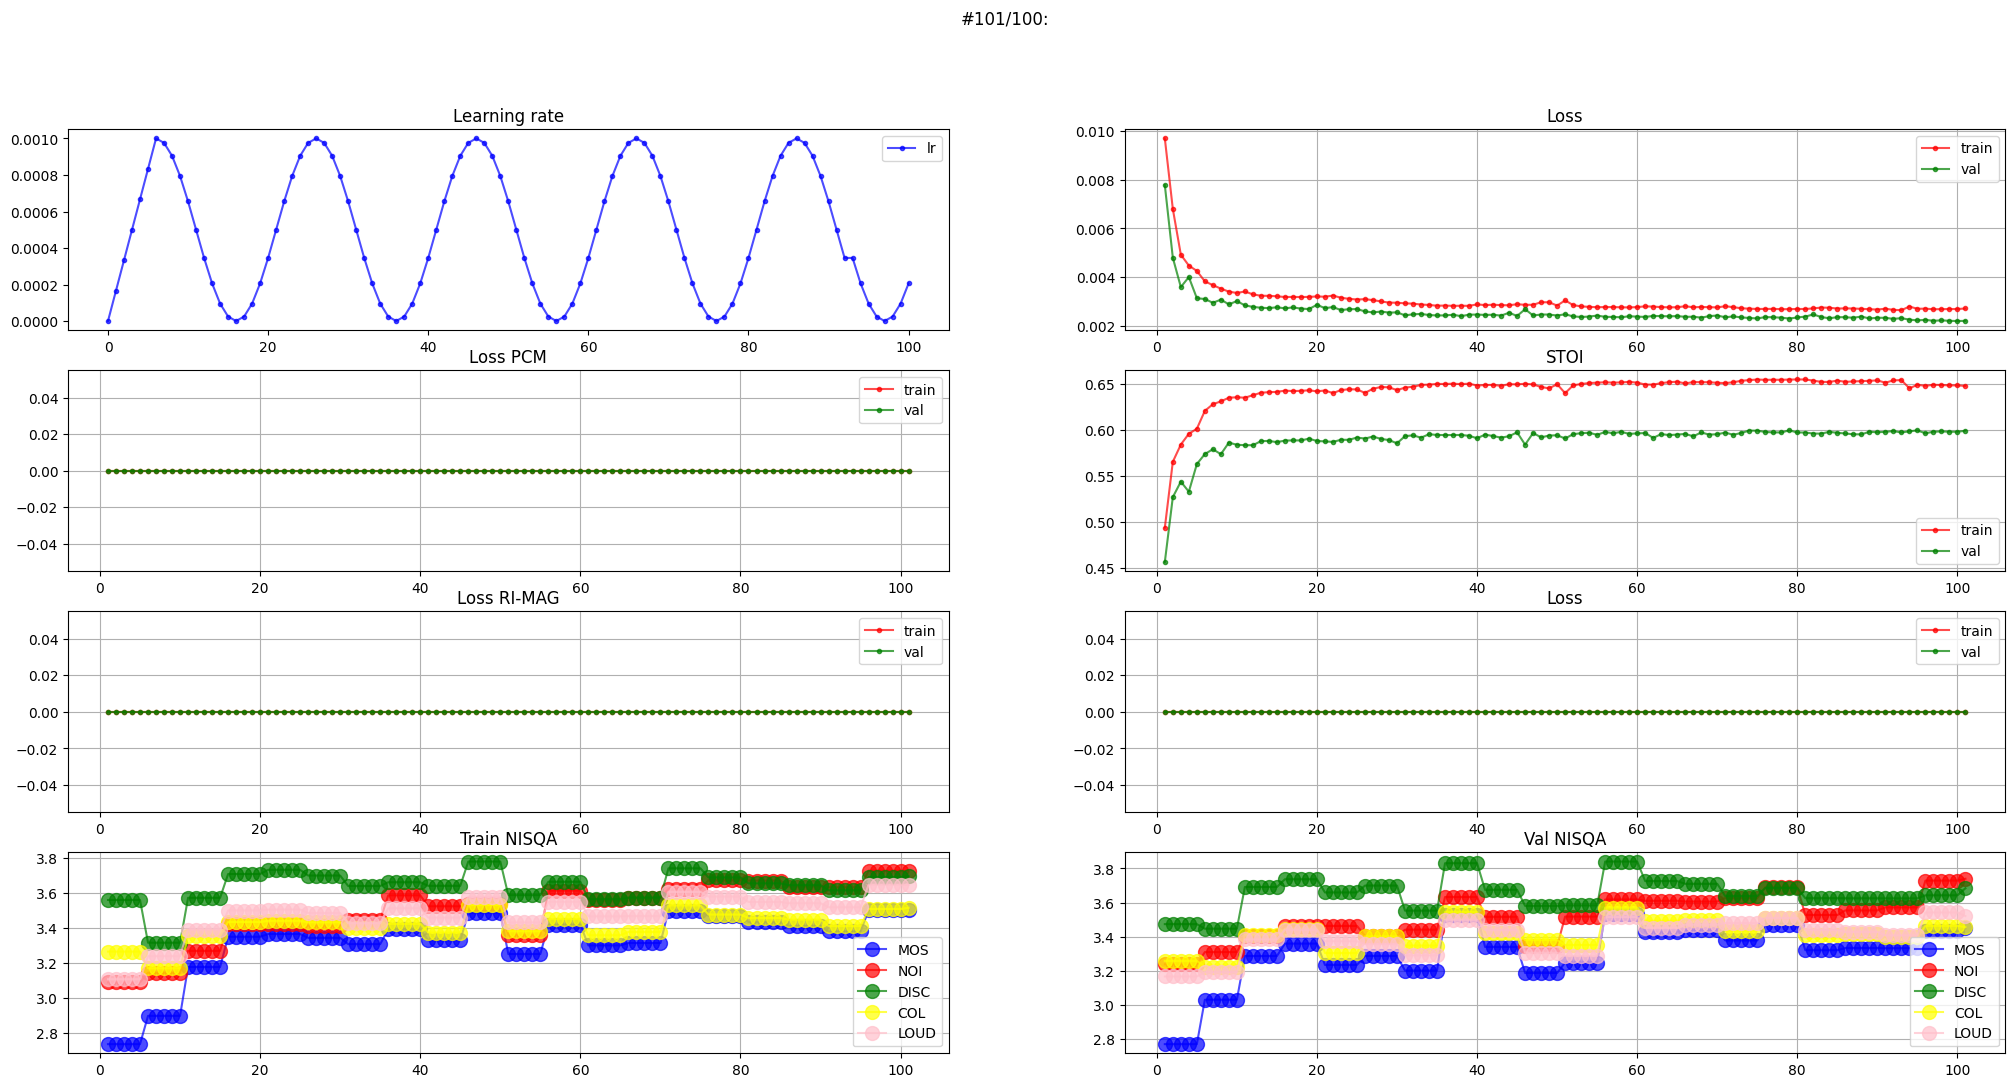

#102/100:


Train model :  89%|████████▉ | 1291/1447 [07:50<00:55,  2.82it/s]Exception in thread Thread-23 (_pin_memory_loop):
Traceback (most recent call last):
  File "/home/zakhar/miniconda3/envs/ems_dereverb/lib/python3.10/threading.py", line 1009, in _bootstrap_inner
    self.run()
  File "/home/zakhar/miniconda3/envs/ems_dereverb/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/home/zakhar/miniconda3/envs/ems_dereverb/lib/python3.10/threading.py", line 946, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zakhar/miniconda3/envs/ems_dereverb/lib/python3.10/site-packages/torch/utils/data/_utils/pin_memory.py", line 53, in _pin_memory_loop
    do_one_step()
  File "/home/zakhar/miniconda3/envs/ems_dereverb/lib/python3.10/site-packages/torch/utils/data/_utils/pin_memory.py", line 30, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
  File "/home/zakhar/miniconda3/envs/ems_dereverb/lib/pyt

KeyboardInterrupt: 

In [ ]:
# fspen, optimizer, plots = learning_loop(fspen, configs, optimizer, train_dataloader, test_dataloader, scheduler, draw_every=1, epochs=100, accumulation_step=1, min_lr=1e-8, with_noise=False, with_rir=False, model_name="TrainConfig_explicit_charisma#2.pt", plots=plots, starting_epoch=state_d["epoch"])